<a href="https://colab.research.google.com/github/zydanne-costa/Ondas_ADCP_SCO_Mar_Nov_2025/blob/main/Vento_ERA_5_SEC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Caminho /content/drive/MyDrive/Ondas/Dados/VENTO_ERA5/Vento_SCO_ERAS5_NOV_2025.csv

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

file_path = '/content/drive/MyDrive/Ondas/VENTO_ERA5/Vento_SCO_ERAS5_NOV_2025.csv'
df = pd.read_csv(file_path, sep=';')

# Display the first 5 rows of the DataFrame
display(df.head())

,system:index,datetime,dir_deg,vel_m_s,.geo
0,20251101T00,01/11/2025 00:00,31.735265,5.996352,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,20251101T01,01/11/2025 01:00,28.101316,5.924250,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,20251101T02,01/11/2025 02:00,27.955073,5.699256,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,20251101T03,01/11/2025 03:00,28.884872,5.217574,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,20251101T04,01/11/2025 04:00,29.854599,4.803355,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [12]:
df_wind = pd.DataFrame()
df_wind['datetime'] = pd.to_datetime(df['datetime'], format='%d/%m/%Y %H:%M')
df_wind['dir_deg'] = df['dir_deg'].round(1)
df_wind['vel_m_s'] = df['vel_m_s'].round(2)

display(df_wind.head())

,datetime,dir_deg,vel_m_s
0,2025-11-01 00:00:00,31.7,6.00
1,2025-11-01 01:00:00,28.1,5.92
2,2025-11-01 02:00:00,28.0,5.70
3,2025-11-01 03:00:00,28.9,5.22
4,2025-11-01 04:00:00,29.9,4.80


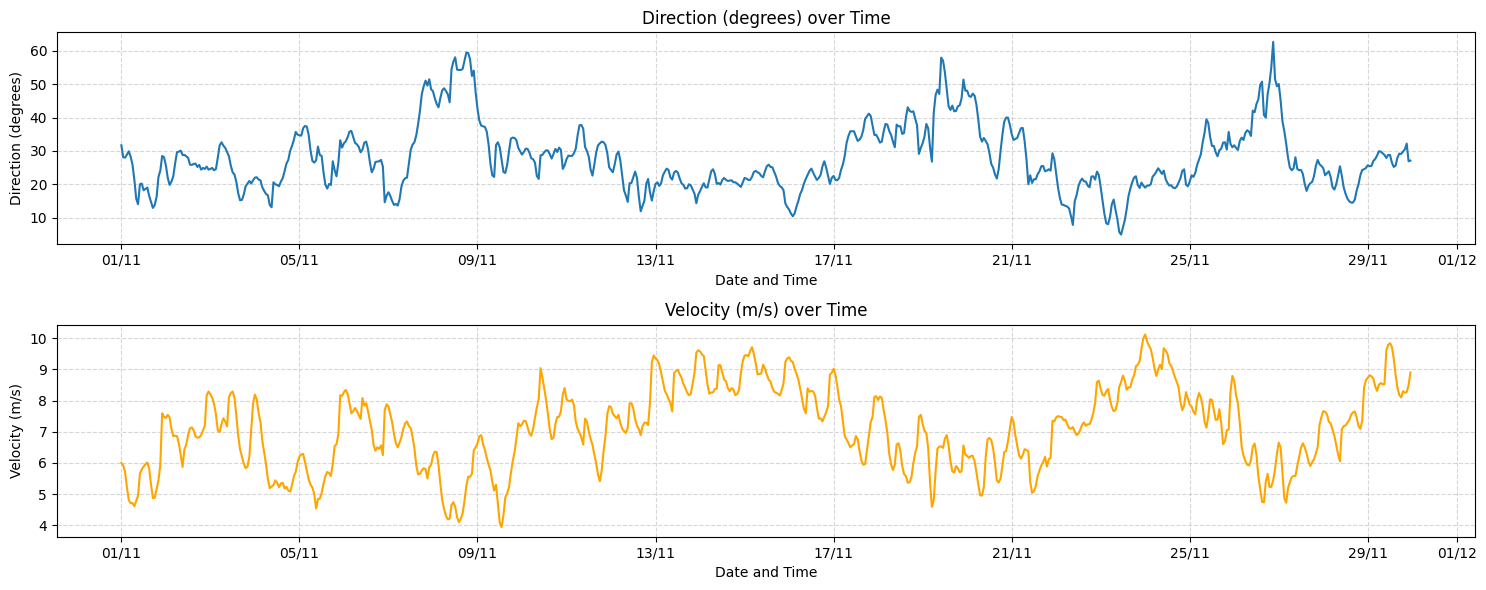

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

plt.figure(figsize=(15, 6))

# Plotting dir_deg vs datetime
ax1 = plt.subplot(2, 1, 1) # 1 row, 2 columns, first plot
sns.lineplot(x='datetime', y='dir_deg', data=df_wind, ax=ax1)
plt.title('Direction (degrees) over Time')
plt.xlabel('Date and Time')
plt.ylabel('Direction (degrees)')
plt.xticks()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m')) # Set date format
plt.grid(True, linestyle='--', alpha=0.5)

# Plotting vel_m_s vs datetime
ax2 = plt.subplot(2, 1, 2) # 1 row, 2 columns, second plot
sns.lineplot(x='datetime', y='vel_m_s', data=df_wind, color='orange', ax=ax2)
plt.title('Velocity (m/s) over Time')
plt.xlabel('Date and Time')
plt.ylabel('Velocity (m/s)')
plt.xticks()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m')) # Set date format
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

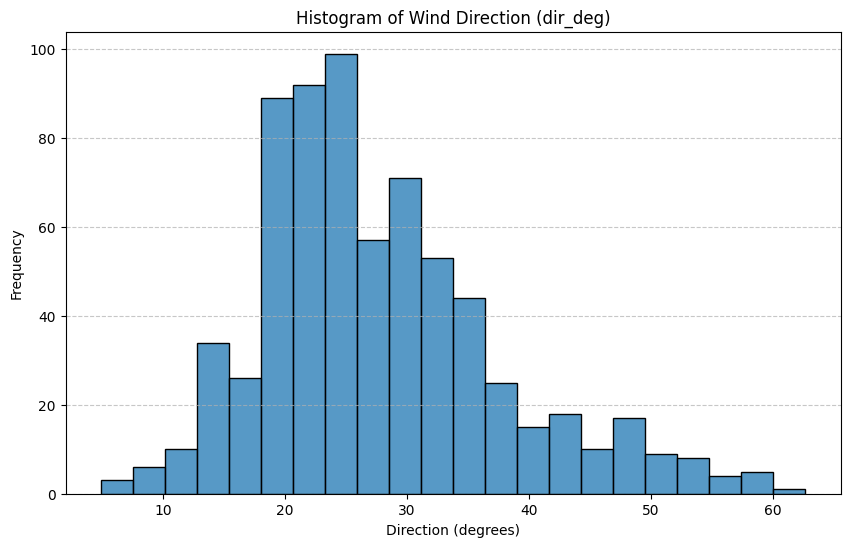

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_wind['dir_deg'], kde=False, edgecolor='black')
plt.title('Histogram of Wind Direction (dir_deg)')
plt.xlabel('Direction (degrees)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [20]:
output_path = '/content/drive/MyDrive/Ondas/Dados/Refinados/Wind_Nov.csv'
df_wind.to_csv(output_path, index=False)
print(f'DataFrame .csv saved to {output_path}')

output_path_txt = '/content/drive/MyDrive/Ondas/Dados/Refinados/Wind_Nov.txt'
df_wind.to_csv(output_path_txt, sep='\t', index=False)
print(f'DataFrame .txt saved to {output_path_txt}')

DataFrame .csv saved to /content/drive/MyDrive/Ondas/Dados/Refinados/Wind_Nov.csv
DataFrame .txt saved to /content/drive/MyDrive/Ondas/Dados/Refinados/Wind_Nov.txt
